🚀 Dispositivo de entrenamiento configurado: cuda
   Nombre de la GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU

📂 Cargando 8 archivos...

📋 CARACTERÍSTICAS A UTILIZAR (Total: 45)
Total Fwd Packets         | Total Backward Packets    | Total Length of Fwd Packe
Total Length of Bwd Packe | Fwd Packet Length Max     | Fwd Packet Length Min    
Fwd Packet Length Mean    | Fwd Packet Length Std     | Bwd Packet Length Max    
Bwd Packet Length Min     | Bwd Packet Length Mean    | Bwd Packet Length Std    
Flow Bytes/s              | Fwd IAT Total             | Fwd IAT Mean             
Fwd IAT Std               | Fwd IAT Max               | Fwd IAT Min              
Bwd IAT Total             | Bwd IAT Mean              | Bwd IAT Std              
Bwd IAT Max               | Bwd IAT Min               | Fwd Header Length        
Bwd Header Length         | Fwd Packets/s             | Bwd Packets/s            
Min Packet Length         | Max Packet Length         | Packet Length Mean       
Pack

Progreso Global CV:   0%|          | 0/30 [00:00<?, ?pliegue/s]

🟢 Rep 1 | Fold 1 -> XGBoost  [Train: 0.8825 | Val: 0.8249 | Test: 0.8246]
🔵 Rep 1 | Fold 1 -> RandFor  [Train: 0.7890 | Val: 0.7375 | Test: 0.7530]
---------------------------------------------------------------------------
🟢 Rep 1 | Fold 2 -> XGBoost  [Train: 0.8453 | Val: 0.8269 | Test: 0.8082]
🔵 Rep 1 | Fold 2 -> RandFor  [Train: 0.7679 | Val: 0.7576 | Test: 0.7358]
---------------------------------------------------------------------------
🟢 Rep 1 | Fold 3 -> XGBoost  [Train: 0.8499 | Val: 0.8346 | Test: 0.8152]
🔵 Rep 1 | Fold 3 -> RandFor  [Train: 0.7574 | Val: 0.7109 | Test: 0.7298]
---------------------------------------------------------------------------
🟢 Rep 1 | Fold 4 -> XGBoost  [Train: 0.8608 | Val: 0.8262 | Test: 0.8118]
🔵 Rep 1 | Fold 4 -> RandFor  [Train: 0.8313 | Val: 0.8061 | Test: 0.7556]
---------------------------------------------------------------------------
🟢 Rep 1 | Fold 5 -> XGBoost  [Train: 0.8512 | Val: 0.8082 | Test: 0.8101]
🔵 Rep 1 | Fold 5 -> RandFor  [

C:\Users\noefp\AppData\Local\Temp\ipykernel_11052\2146018132.py:357: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Modelo', y='F1_Macro', data=df_melted, palette='Set2', width=0.4, showmeans=True,


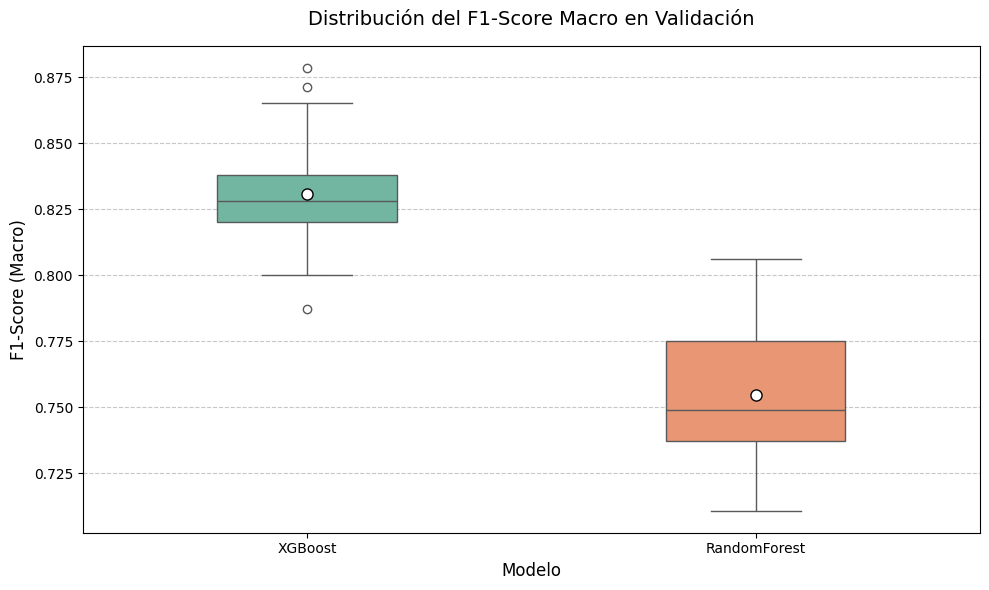


🏆 RANKING OFICIAL DE MODELOS:


,Modelo,F1_Macro_Promedio,Desviacion_Std
Posición,,,
1,XGBoost,0.830799,0.019875
2,Random Forest,0.754460,0.025217


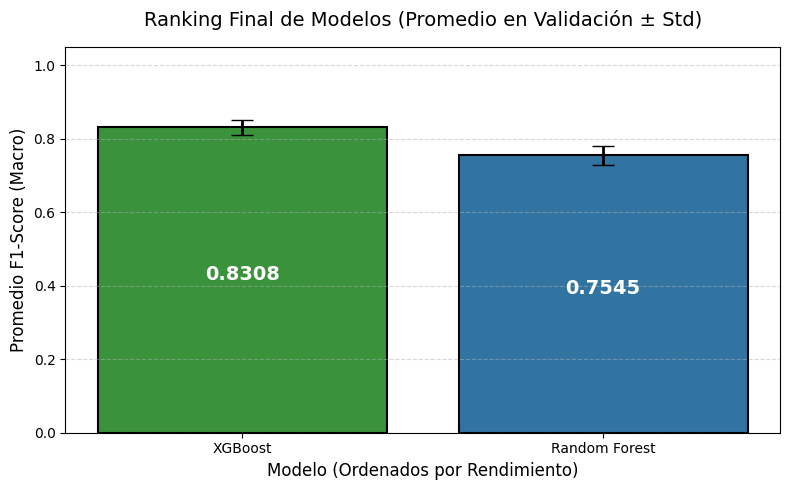


🎯 PARTE 8: MATRICES DE CONFUSIÓN (CORRIDA REPRESENTATIVA / MEDIANA)
Seleccionando la corrida cuyo F1 de Validación sea el más cercano a la mediana matemática...

🔹 XGBoost - Corrida representativa: #14
   F1-Macro en Validación de esta corrida: 0.8275 (Mediana: 0.8279)

🏆 REPORTE DE EVALUACIÓN: XGBoost (Mediana - Corrida 14) SOBRE TEST
🎯 F1-Score (Macro): 0.8274

📋 Reporte Detallado (Precision, Recall, F1 por Clase):
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    340881
                       Bot       0.42      0.99      0.59       295
                      DDoS       1.00      1.00      1.00     19204
             DoS GoldenEye       0.96      1.00      0.98      1544
                  DoS Hulk       1.00      1.00      1.00     34519
          DoS Slowhttptest       0.89      0.99      0.94       825
             DoS slowloris       0.98      0.99      0.99       869
               FTP-Patator       

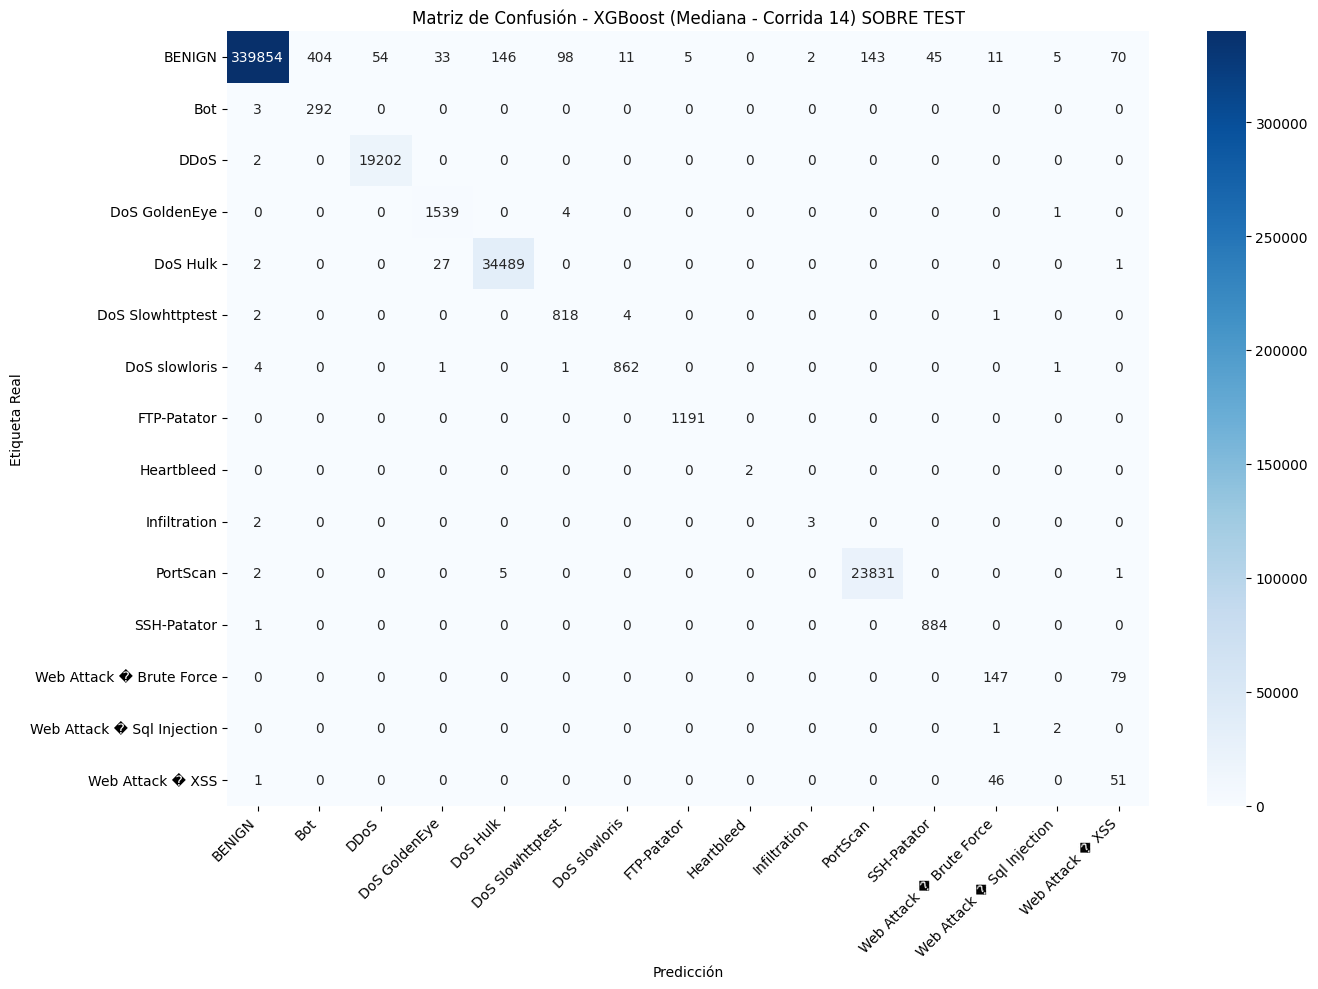

🔹 Random Forest - Corrida representativa: #10
   F1-Macro en Validación de esta corrida: 0.7491 (Mediana: 0.7489)

🏆 REPORTE DE EVALUACIÓN: Random Forest (Mediana - Corrida 10) SOBRE TEST
🎯 F1-Score (Macro): 0.7684

📋 Reporte Detallado (Precision, Recall, F1 por Clase):
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.98      0.99    340881
                       Bot       0.07      0.99      0.13       295
                      DDoS       0.99      1.00      1.00     19204
             DoS GoldenEye       0.97      1.00      0.98      1544
                  DoS Hulk       0.93      1.00      0.96     34519
          DoS Slowhttptest       0.94      0.99      0.96       825
             DoS slowloris       0.99      0.99      0.99       869
               FTP-Patator       0.99      1.00      0.99      1191
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.20 

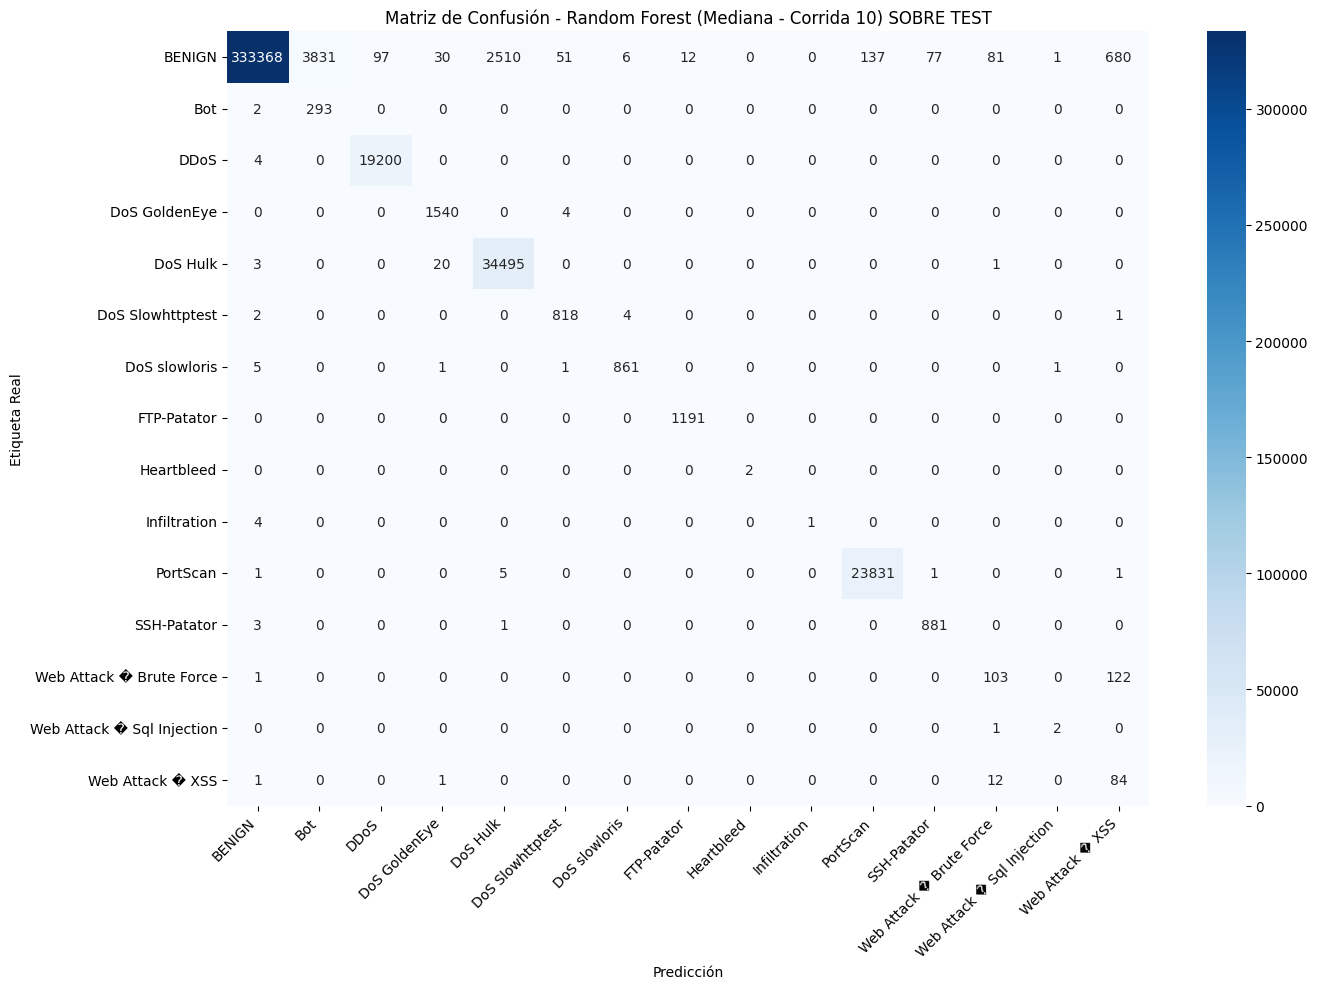

In [ ]:
import os
import glob
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from collections import Counter
from tqdm.notebook import tqdm
from IPython.display import display

# ==========================================
# 1. Configuración de Hardware (CUDA)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Dispositivo de entrenamiento configurado: {device}")
if device.type == 'cuda':
    print(f"   Nombre de la GPU: {torch.cuda.get_device_name(0)}")

# ==========================================
# 2. Carga y Consolidación de Datos
# ==========================================
ruta_limpieza = r"C:/Users/noefp/Documents/Ciencia-CIC-2017/Limpieza"
archivos_limpios = glob.glob(os.path.join(ruta_limpieza, "*-limpio.csv"))

print(f"\n📂 Cargando {len(archivos_limpios)} archivos...")
df_list = [pd.read_csv(f, low_memory=False) for f in archivos_limpios]
df = pd.concat(df_list, ignore_index=True)
df.columns = df.columns.str.strip()

# ==========================================
# 2.5 FILTRADO DE CARACTERÍSTICAS Y REPORTE
# ==========================================
columnas_ignorar = ['Destination Port']
caracteristicas_finales = [col for col in df.columns if col not in ['Label'] + columnas_ignorar]

print("\n" + "="*60)
print(f"📋 CARACTERÍSTICAS A UTILIZAR (Total: {len(caracteristicas_finales)})")
print("="*60)
for i in range(0, len(caracteristicas_finales), 3):
    chunk = caracteristicas_finales[i:i+3]
    print(" | ".join([f"{c[:25]:<25}" for c in chunk]))
print(f"\n🚫 Columnas ignoradas intencionalmente: {columnas_ignorar}")
print("="*60 + "\n")

# ==========================================
# 3. Separación de X e y, y ANÁLISIS DE CLASES
# ==========================================
if 'Label' not in df.columns:
    raise ValueError("No se encontró la columna 'Label'. Verifica el nombre en tu dataset.")

columnas_a_quitar = ['Label'] + [col for col in columnas_ignorar if col in df.columns]
X_raw = df.drop(columns=columnas_a_quitar).values
y_raw = df['Label'].values

del df, df_list 

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_raw)
clases_nombres = encoder.classes_
num_classes = len(clases_nombres)

print("\n" + "="*40)
print("📊 RESUMEN DE CLASES EN EL DATASET GLOBAL")
print("="*40)
conteo_clases = Counter(y_encoded)
for clase_idx, cantidad in conteo_clases.items():
    nombre_clase = clases_nombres[clase_idx]
    porcentaje = (cantidad / len(y_encoded)) * 100
    print(f"🔹 {nombre_clase:<20} : {cantidad:>10} instancias ({porcentaje:>6.2f}%)")
print("="*40 + "\n")

# ==========================================
# 4. Partición y Preparación 
# ==========================================

# 1. Separamos Test (15%) y lo que queda es nuestro conjunto de desarrollo (85%)
X_dev, X_test, y_dev, y_test = train_test_split(X_raw, y_encoded, test_size=0.15, random_state=42, stratify=y_encoded)

print("⚖️ Calculando pesos para balanceo de clases (Sobre todo el conjunto de desarrollo)...")

# ==========================================
# FUNCIÓN DE EVALUACIÓN
# ==========================================
def evaluar_modelo(nombre_modelo, y_true, y_pred, clases):
    print(f"\n{'='*60}\n🏆 REPORTE DE EVALUACIÓN: {nombre_modelo}\n{'='*60}")
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"🎯 F1-Score (Macro): {macro_f1:.4f}")
    print("\n📋 Reporte Detallado (Precision, Recall, F1 por Clase):")
    print(classification_report(y_true, y_pred, target_names=clases, zero_division=0))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(14, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clases, yticklabels=clases)
    plt.title(f'Matriz de Confusión - {nombre_modelo}')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Predicción')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


from sklearn.utils.class_weight import compute_sample_weight
# ==========================================
# PREPARACIÓN DE LOS MODELOS ÓPTIMOS 
# ==========================================
xgb_optimo = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    tree_method='hist',      
    eval_metric='mlogloss',
    learning_rate=0.08,         
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    max_delta_step=1,
    n_estimators=150,         
    random_state=42,

    reg_alpha=1,             # Regularización L1 (apaga características ruidosas)
    reg_lambda=2.5,            # Regularización L2 (suaviza decisiones extremas)
    gamma=0.2,
)

rf_optimo = RandomForestClassifier(
    n_estimators=200,
    max_depth=17,
    class_weight='balanced',
    n_jobs=-1,                 
    random_state=42,
    min_samples_split=10,      # Un nodo necesita mínimo 10 datos para atreverse a dividirse.
    min_samples_leaf=4         # Las "hojas" finales deben tener al menos 4 datos, evitando hojas con 1 solo dato anómalo.
)

## ==========================================
# PARTE 4: DISEÑO EXPERIMENTAL (TRAIN, VAL Y TEST)
# ==========================================
n_splits = 5
n_repeats = 6 
total_ejecuciones = n_splits * n_repeats

print("\n🔄 PARTE 4: Iniciando Validación Cruzada Estratificada Repetida")
print(f"Configuración: k={n_splits} folds, {n_repeats} repeticiones (Total: {total_ejecuciones} ejecuciones)\n")

# Se usa X_dev (85% de los datos totales)
cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

scores_train_xgb, scores_val_xgb, scores_test_xgb = [], [], []
scores_train_rf, scores_val_rf, scores_test_rf = [], [], []
preds_test_xgb_all = []
preds_test_rf_all = []

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="xgboost")

with tqdm(total=total_ejecuciones, desc="Progreso Global CV", unit="pliegue") as pbar:
    

    for i, (train_idx, val_idx) in enumerate(cv.split(X_dev, y_dev)):
        
        rep_actual = (i // n_splits) + 1
        fold_actual = (i % n_splits) + 1
        
        # 1. Separamos los datos del pliegue (
        X_train_cv_raw, X_val_cv_raw = X_dev[train_idx], X_dev[val_idx]
        y_train_cv, y_val_cv = y_dev[train_idx], y_dev[val_idx]
        
        scaler = StandardScaler()
        # El scaler SOLO ve y aprende del Train de este pliegue específico
        X_train_cv = scaler.fit_transform(X_train_cv_raw)
        
        # Transforma Validacion y Test usando la media/std del Train actual
        X_val_cv = scaler.transform(X_val_cv_raw)
        X_test_scaled_cv = scaler.transform(X_test) # Escalamos test en cada vuelta para mantener coherencia
        
        # ==========================================
        # Entrenamiento XGBoost
    
        pesos_muestras_train = compute_sample_weight('balanced', y_train_cv)
        
        # Entrenar XGBoost obligándolo a prestar atención a las clases minoritarias
        xgb_optimo.fit(
            X_train_cv, 
            y_train_cv, 
            sample_weight=pesos_muestras_train, 
            verbose=False
        )
        
        # Evaluar en Train
        preds_train_xgb = xgb_optimo.predict(X_train_cv)
        s_train_xgb = f1_score(y_train_cv, preds_train_xgb, average='macro', zero_division=0)
        scores_train_xgb.append(s_train_xgb)
        
        # Evaluar en Val
        preds_val_xgb = xgb_optimo.predict(X_val_cv)
        s_val_xgb = f1_score(y_val_cv, preds_val_xgb, average='macro', zero_division=0)
        scores_val_xgb.append(s_val_xgb)
        
        # Evaluar en Test (Usando el Test recién escalado)
        preds_test_xgb = xgb_optimo.predict(X_test_scaled_cv)
        s_test_xgb = f1_score(y_test, preds_test_xgb, average='macro', zero_division=0)
        scores_test_xgb.append(s_test_xgb)
        preds_test_xgb_all.append(preds_test_xgb)
        
        pbar.write(f"🟢 Rep {rep_actual} | Fold {fold_actual} -> XGBoost  [Train: {s_train_xgb:.4f} | Val: {s_val_xgb:.4f} | Test: {s_test_xgb:.4f}]")
        
        
        # ==========================================
        # Entrenamiento Random Forest
        # ==========================================

        rf_optimo.fit(
            X_train_cv, 
            y_train_cv,
            sample_weight=pesos_muestras_train 
        )
        
        preds_train_rf = rf_optimo.predict(X_train_cv)
        s_train_rf = f1_score(y_train_cv, preds_train_rf, average='macro', zero_division=0)
        scores_train_rf.append(s_train_rf)
        
        preds_val_rf = rf_optimo.predict(X_val_cv)
        s_val_rf = f1_score(y_val_cv, preds_val_rf, average='macro', zero_division=0)
        scores_val_rf.append(s_val_rf)
        
        preds_test_rf = rf_optimo.predict(X_test_scaled_cv)
        s_test_rf = f1_score(y_test, preds_test_rf, average='macro', zero_division=0)
        scores_test_rf.append(s_test_rf)
        preds_test_rf_all.append(preds_test_rf)
        
        pbar.write(f"🔵 Rep {rep_actual} | Fold {fold_actual} -> RandFor  [Train: {s_train_rf:.4f} | Val: {s_val_rf:.4f} | Test: {s_test_rf:.4f}]")
        pbar.write("-" * 75)
        
        pbar.update(1)

warnings.filterwarnings("default", module="xgboost")
print("✅ Validación Cruzada Completada.")

# ==========================================
# PARTE 5: EVALUACIÓN DE RESULTADOS Y EXPORTACIÓN
# ==========================================
print("\n📊 PARTE 5: Exportación de Resultados (Train, Val y Test)")

df_resultados = pd.DataFrame({
    'Ejecucion': np.arange(1, total_ejecuciones + 1),
    'XGBoost_Train_F1': scores_train_xgb,
    'XGBoost_Val_F1': scores_val_xgb,
    'XGBoost_Test_F1': scores_test_xgb,
    'RandomForest_Train_F1': scores_train_rf,
    'RandomForest_Val_F1': scores_val_rf,
    'RandomForest_Test_F1': scores_test_rf
})

archivo_csv = "resultados_cv_modelos_completos.csv"
df_resultados.to_csv(archivo_csv, index=False)
print(f"💾 Resultados de las 30 corridas guardados en: {archivo_csv}")

# ==========================================
# PARTE 6: ANÁLISIS ESTADÍSTICO (COMPARACIÓN DE MODELOS EN VALIDACIÓN)
# ==========================================
def calcular_estadisticas(scores, nombre_modelo, conjunto):
    stats_dict = {
        'Mínimo': np.min(scores),
        'Máximo': np.max(scores),
        'Mediana': np.median(scores),
        'Promedio': np.mean(scores),
        'Desv. Est.': np.std(scores)
    }
    print(f"\nEstadísticas {nombre_modelo} ({conjunto}):")
    for k, v in stats_dict.items():
        print(f"  - {k:<12}: {v:.4f}")
    return stats_dict

print("\n" + "="*60)
print("📈 ESTADÍSTICAS GLOBALES EN VALIDACIÓN")
print("="*60)
stats_xgb_val = calcular_estadisticas(scores_val_xgb, "XGBoost", "Validación")
stats_rf_val = calcular_estadisticas(scores_val_rf, "Random Forest", "Validación")


print("\n" + "="*60)
print("⚖️ ANÁLISIS DE HIPÓTESIS ESTADÍSTICA")
print("="*60)

alpha = 0.05
print(f"Nivel de significancia (α) = {alpha}\n")
print("H0 (Nula): No hay diferencia estadísticamente significativa en el F1-Macro entre XGBoost y Random Forest en Validación.")
print("H1 (Alternativa): Existe una diferencia estadísticamente significativa entre los modelos.\n")

scores_xgb_arr = np.array(scores_val_xgb)
scores_rf_arr = np.array(scores_val_rf)

# Paso 1: Prueba de Normalidad sobre las diferencias
diferencias = scores_xgb_arr - scores_rf_arr
stat_shapiro, p_shapiro = stats.shapiro(diferencias)

print(f"1️⃣ Prueba de Normalidad (Shapiro-Wilk) de las diferencias:")
print(f"   p-value = {p_shapiro:.4f}")

if p_shapiro > alpha:
    print("   -> Las diferencias siguen una distribución normal. Se utilizará t de Student pareada.")
    stat_test, p_value = stats.ttest_rel(scores_xgb_arr, scores_rf_arr)
    prueba_usada = "t de Student pareada"
else:
    print("   -> Las diferencias NO siguen una distribución normal. Se utilizará la prueba no paramétrica de Wilcoxon.")
    stat_test, p_value = stats.wilcoxon(scores_xgb_arr, scores_rf_arr)
    prueba_usada = "Rango con signo de Wilcoxon"

print(f"\n2️⃣ Resultados de la prueba ({prueba_usada}):")
print(f"   Estadístico = {stat_test:.4f}")
print(f"   p-value     = {p_value:.4e}")

print("\n🎯 CONCLUSIÓN ESTADÍSTICA:")
if p_value < alpha:
    mejor_modelo = "XGBoost" if np.mean(scores_xgb_arr) > np.mean(scores_rf_arr) else "Random Forest"
    print(f"Dado que el p-value ({p_value:.4e}) es menor que α ({alpha}), RECHAZAMOS la hipótesis nula (H0).")
    print(f"El modelo estadísticamente superior es: **{mejor_modelo}**.")
else:
    print(f"Dado que el p-value ({p_value:.4f}) es mayor o igual que α ({alpha}), NO PODEMOS RECHAZAR la hipótesis nula (H0).")
    print("No existe evidencia estadística para afirmar que un modelo es superior al otro.")

# ==========================================
# PARTE 7: VISUALIZACIONES Y RANKING
# ==========================================
print("\n📈 PARTE 7: Generando Visualizaciones y Ranking...")

# ---------------------------------------------------------
# 1. Boxplot (Distribución)
# ---------------------------------------------------------
df_melted = df_resultados.melt(id_vars=['Ejecucion'], 
                               value_vars=['XGBoost_Val_F1', 'RandomForest_Val_F1'],
                               var_name='Modelo', value_name='F1_Macro')
df_melted['Modelo'] = df_melted['Modelo'].str.replace('_Val_F1', '')

plt.figure(figsize=(10, 6))
sns.boxplot(x='Modelo', y='F1_Macro', data=df_melted, palette='Set2', width=0.4, showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})
plt.title('Distribución del F1-Score Macro en Validación', fontsize=14, pad=15)
plt.ylabel('F1-Score (Macro)', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. Ranking Oficial y Gráfico de Barras
# ---------------------------------------------------------
print("\n🏆 RANKING OFICIAL DE MODELOS:")
df_ranking = pd.DataFrame([
    {'Modelo': 'XGBoost', 'F1_Macro_Promedio': stats_xgb_val['Promedio'], 'Desviacion_Std': stats_xgb_val['Desv. Est.']},
    {'Modelo': 'Random Forest', 'F1_Macro_Promedio': stats_rf_val['Promedio'], 'Desviacion_Std': stats_rf_val['Desv. Est.']}
]).sort_values(by='F1_Macro_Promedio', ascending=False).reset_index(drop=True)
df_ranking.index = np.arange(1, len(df_ranking) + 1)
df_ranking.index.name = 'Posición'
display(df_ranking)

plt.figure(figsize=(8, 5))
colores_ranking = ['#2ca02c' if i == 0 else '#1f77b4' for i in range(len(df_ranking))]
sns.barplot(x='Modelo', y='F1_Macro_Promedio', data=df_ranking, 
            hue='Modelo', palette=colores_ranking, linewidth=1.5, edgecolor="black", legend=False)
plt.errorbar(x=range(len(df_ranking)), y=df_ranking['F1_Macro_Promedio'], 
             yerr=df_ranking['Desviacion_Std'], fmt='none', c='black', capsize=8, linewidth=2)
for index, row in df_ranking.reset_index(drop=True).iterrows():
    plt.text(index, row['F1_Macro_Promedio'] / 2, f"{row['F1_Macro_Promedio']:.4f}", 
             color='white', ha="center", weight='bold', fontsize=14)

plt.title('Ranking Final de Modelos (Promedio en Validación ± Std)', fontsize=14, pad=15)
plt.ylabel('Promedio F1-Score (Macro)', fontsize=12)
plt.xlabel('Modelo (Ordenados por Rendimiento)', fontsize=12)
plt.ylim(0, 1.05) 
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ==========================================
# PARTE 8: MATRIZ DE CONFUSIÓN DE LA MEDIANA (SOBRE TEST)
# ==========================================
print("\n" + "="*60)
print("🎯 PARTE 8: MATRICES DE CONFUSIÓN (CORRIDA REPRESENTATIVA / MEDIANA)")
print("="*60)
print("Seleccionando la corrida cuyo F1 de Validación sea el más cercano a la mediana matemática...\n")

# -- Lógica XGBoost --
mediana_val_xgb = np.median(scores_val_xgb)
# Buscar el índice (corrida) más cercano a la mediana
idx_mediana_xgb = np.argmin(np.abs(np.array(scores_val_xgb) - mediana_val_xgb))
preds_mediana_test_xgb = preds_test_xgb_all[idx_mediana_xgb]

print(f"🔹 XGBoost - Corrida representativa: #{idx_mediana_xgb + 1}")
print(f"   F1-Macro en Validación de esta corrida: {scores_val_xgb[idx_mediana_xgb]:.4f} (Mediana: {mediana_val_xgb:.4f})")
evaluar_modelo(f"XGBoost (Mediana - Corrida {idx_mediana_xgb + 1}) SOBRE TEST", y_test, preds_mediana_test_xgb, clases_nombres)

# -- Lógica Random Forest --
mediana_val_rf = np.median(scores_val_rf)
# Buscar el índice (corrida) más cercano a la mediana
idx_mediana_rf = np.argmin(np.abs(np.array(scores_val_rf) - mediana_val_rf))
preds_mediana_test_rf = preds_test_rf_all[idx_mediana_rf]

print(f"🔹 Random Forest - Corrida representativa: #{idx_mediana_rf + 1}")
print(f"   F1-Macro en Validación de esta corrida: {scores_val_rf[idx_mediana_rf]:.4f} (Mediana: {mediana_val_rf:.4f})")
evaluar_modelo(f"Random Forest (Mediana - Corrida {idx_mediana_rf + 1}) SOBRE TEST", y_test, preds_mediana_test_rf, clases_nombres)